In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper, BravyiKitaevMapper

In [3]:
atom_string = f"H 0 0 0; H 0 0 {0.25}"

driver = PySCFDriver(
    atom=atom_string,
    basis='sto3g', # Menggunakan dict kustom
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

es_problem = driver.run()
second_q_op = es_problem.hamiltonian.second_q_op()

mapper_par = ParityMapper(num_particles=es_problem.num_particles)
mapper_jw = JordanWignerMapper()
mapper_bk = BravyiKitaevMapper()
qubit_jw = mapper_jw.map(second_q_op)
qubit_par = mapper_par.map(second_q_op)
qubit_bk = mapper_bk.map(second_q_op)

In [15]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Asumsi driver, es_problem, mapper_jw, dan qubit_jw sudah dijalankan seperti di atas

def load_all_tests(type, version):
    """
    Membaca semua predicted_data_1.csv dari folder test_*
    dan mengembalikan satu DataFrame besar dengan kolom 'dataset'
    sebagai penanda asal folder (test_01, test_02, dst).
    """
    dataframes = []
    base_dir = f'../hasil_eksperimenV{version}_parity/{type}'
    rel_path = ('ml_training', 'train_data', 'train_data_1.csv')

    for test_dir in sorted(os.listdir(base_dir)):
        csv_path = os.path.join(base_dir, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir   # penanda asal data
            dataframes.append(df)
        else:
            print(f"Peringatan: file tidak ditemukan: {csv_path}")

    if not dataframes:
        raise FileNotFoundError(
            f"Tidak ada file predicted_data_1.csv yang ditemukan di folder {base_dir}"
        )

    return pd.concat(dataframes, ignore_index=True)


# 1. Definisikan dictionary versi dan nama backend-nya
versions_to_run = {
    '10': 'FakeAthensV2',
    '12': 'FakeBelemV2'
}

metrik = []

# 2. Loop melalui kedua versi
for version, backend_name in versions_to_run.items():
    df = load_all_tests('single', version)
    
    # Hitung metrik di level baris
    df["pred_abs_err"] = (df['noisy_energy'] - df["ideal_energy"])**2
    df['variance_ideal'] = 1 - (df['ideal_energy'])**2
    df['variance_noisy'] = 1 - (df['noisy_energy'])**2

    # Loop berdasarkan observable dari Pauli strings
    for obs, coeff in qubit_bk.to_list():
        obs_df = df[df['observable'] == obs]
        
        # Lewati jika observable tidak ditemukan di data
        if obs_df.empty:
            continue
            
        variance_ideal = (obs_df['variance_ideal']).abs().mean()
        variance_noisy = (obs_df['variance_noisy']).abs().mean()
        variance_weight = (coeff.real * obs_df['variance_ideal']).abs().mean()
        L2 = obs_df["pred_abs_err"].sum()
        variansi = obs_df['noisy_energy'].std() 
        
        # stochastic noise
        error_raw = obs_df['noisy_energy'] - obs_df['ideal_energy']
        bias_systematic = error_raw.mean()  
        noise_stochastic = error_raw.std()  
        
        # Simpan ke list dengan tambahan kolom "Backend"
        metrik.append({
            'Observable': obs, 
            'pauli string variance': variance_ideal,
            'variance_noisy': variance_noisy,
            'L2 error' : np.sqrt(L2),
            'std data': variansi, 
            'variance weighted': variance_weight,
            'error_var' : noise_stochastic,
            'Backend': backend_name  # Penanda data berasal dari backend mana
        })

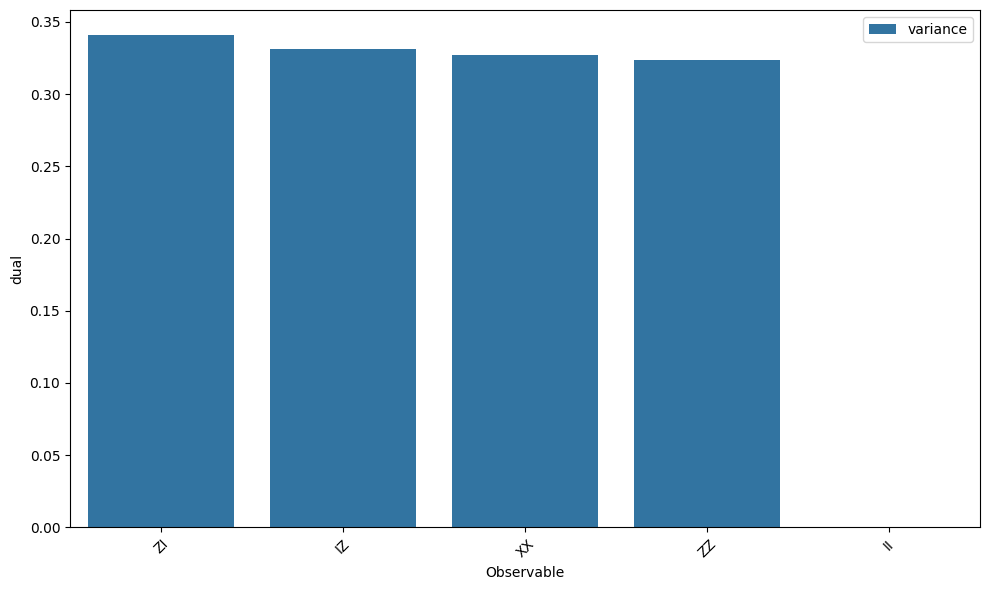

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Contoh pemakaian:
df = load_all_tests('single','10')

params = [f'param_{i}' for i in range(12)]
target = 'ideal_energy'
observables = df['observable'].unique()

df["pred_abs_err"] = (df['noisy_energy'] - df["ideal_energy"])**2
df['variance_ideal'] = 1-(df['ideal_energy'])**2
df['variance_noisy'] = 1-(df['noisy_energy'])**2


# Table to store partial derivative estimates (slopes)
metrik = []

for obs,coeff in qubit_par.to_list():
    
    obs_df = df[df['observable'] == obs]
    
    # Get the variance of the target column
    variance_ideal = (obs_df['variance_ideal']).abs().mean()
    variance_noisy = (obs_df['variance_noisy']).abs().mean()
    variance_weight = (coeff.real*obs_df['variance_ideal']).abs().mean()
    L2 = obs_df["pred_abs_err"].sum()
    variansi = obs_df['ideal_energy'].var()
    
    #stochastic noise
    error_raw = obs_df['noisy_energy'] - obs_df['ideal_energy']
    bias_systematic = error_raw.mean()  # Pergeseran rata-rata
    noise_stochastic = error_raw.std()  # Seberapa "lebar" sebaran noise-nya
    
    # Optionally store it in your list
    metrik.append({'dataset': obs, 
                        'pauli string variance': variance_ideal,
                        'variance_noisy': variance_noisy,
                        'L2 error' : np.sqrt(L2),
                        'variance': variansi, 
                        'variance weighted': variance_weight,
                        'error_var' : noise_stochastic
                        })

# 2. Create a summary DataFrame for plotting
variance_df = pd.DataFrame(metrik).sort_values(by='variance', ascending=False)
melt_df = variance_df.melt(id_vars='dataset', 
                        value_vars=['variance'], 
                        var_name='Kategori_Data', 
                        value_name='dual')
# 3. Create the plot
plot= 'dual'
plt.figure(figsize=(10, 6))
sns.barplot(data=melt_df, x='dataset', y=plot,hue='Kategori_Data')

# plt.title(f'Variance of {target} by Observable')
plt.xlabel('Observable')
plt.ylabel(plot)
plt.legend(loc='upper right') 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

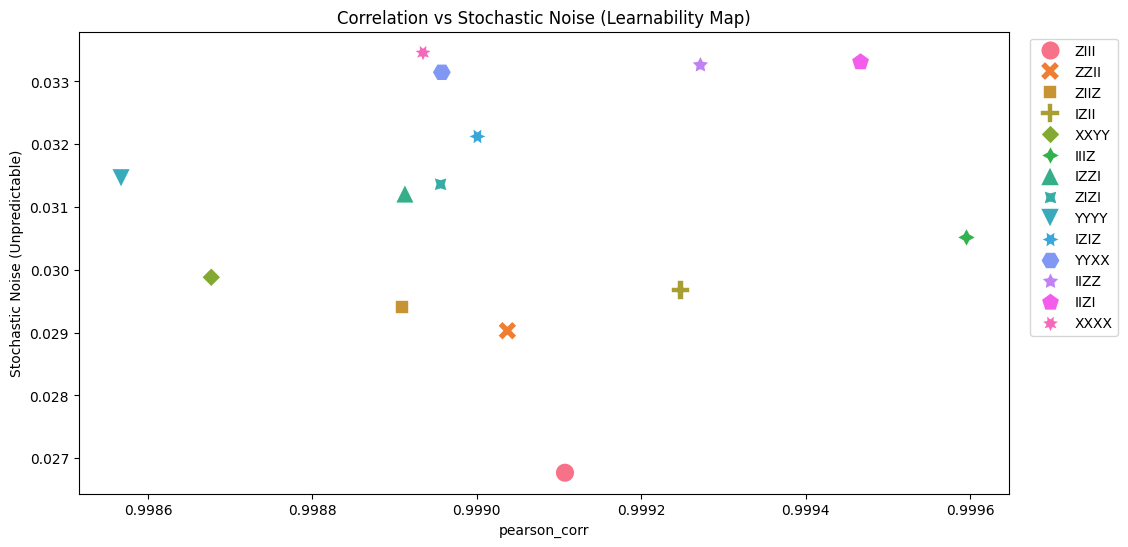

In [30]:
import scipy.stats as stats

metrik = []

for obs, coeff in qubit_op.to_list():
    if obs == 'IIII':
        continue
    obs_df = df[df['observable'] == obs]
    
    # --- Metrik Eksisting ---
    variance_ideal = (obs_df['variance_ideal']).abs().mean()
    variance_noisy = (obs_df['variance_noisy']).abs().mean()
    variansi = obs_df['noisy_energy'].std() 
    
    # --- Metrik Baru: Hubungan Noisy vs Ideal ---
    # 1. Korelasi (Seberapa linear noise-nya?)
    # Jika data konstan, korelasi return NaN, jadi kita handle dengan 0
    if obs_df['ideal_energy'].std() == 0 or obs_df['noisy_energy'].std() == 0:
        pearson_corr = 0
    else:
        pearson_corr, _ = stats.pearsonr(obs_df['ideal_energy'], obs_df['noisy_energy'])
    
    # 2. Dekomposisi Error (Systematic vs Stochastic)
    error_raw = obs_df['noisy_energy'] - obs_df['ideal_energy']
    bias_systematic = error_raw.mean()  # Pergeseran rata-rata
    noise_stochastic = error_raw.std()  # Seberapa "lebar" sebaran noise-nya
    
    # 3. Ratio (Prediktabilitas)
    # Semakin tinggi ratio ini, semakin dominan pola sistematis dibanding acak -> Model makin bagus
    predictability_ratio = abs(bias_systematic) / (noise_stochastic + 1e-9)

    metrik.append({
        'dataset': obs, 
        'variansi' : variansi,
        'variance_ideal': variance_ideal,
        'variance_noisy': variance_noisy,
        'pearson_corr': pearson_corr,      # Metrik Baru
        'bias_shift': bias_systematic,     # Metrik Baru
        'stochastic_noise': noise_stochastic, # Metrik Baru
        'pred_ratio': predictability_ratio, # Metrik Baru
        'coeff_mag': abs(coeff.real)       # Penting: Bobot Pauli
    })

# Plotting korelasi untuk melihat pola
variance_df = pd.DataFrame(metrik).sort_values(by='stochastic_noise', ascending=True)

plt.figure(figsize=(12, 6))
# Cek apakah observable dengan korelasi rendah memiliki stochastic noise tinggi
sns.scatterplot(data=variance_df, x='pearson_corr', y='stochastic_noise', hue='dataset', s=200, style="dataset")
plt.title('Correlation vs Stochastic Noise (Learnability Map)')
plt.legend(bbox_to_anchor=(1.125, 1), loc='upper right')
plt.xlabel('pearson_corr')
plt.ylabel('Stochastic Noise (Unpredictable)')
plt.show()

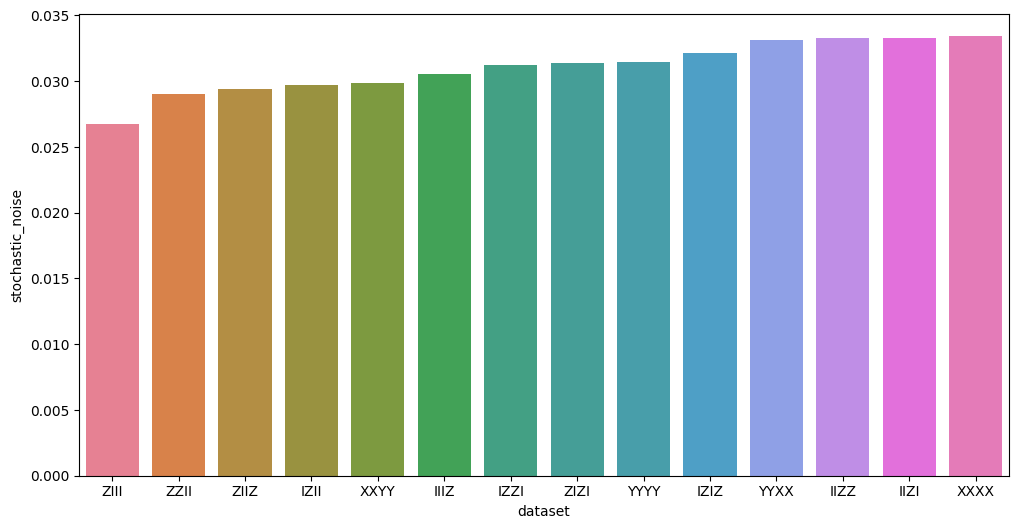

In [138]:
plt.figure(figsize=(12, 6))
# Cek apakah observable dengan korelasi rendah memiliki stochastic noise tinggi
sns.barplot(data=variance_df, x= 'dataset', y='stochastic_noise', hue='dataset')
plt.show()

In [58]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# 1. Tentukan fitur dan target
# Kita abaikan kolom 'dataset' dan 'observable' (karena string) saat perhitungan MI
target_col = 'ideal_energy'
features = ['noisy_energy']

results = []

# 2. Iterasi untuk setiap variabel unik di kolom 'dataset'
for group_name, group_data in df.groupby('observable'):
    X = group_data[features]
    y = group_data[target_col]
    
    # Hitung Mutual Information
    # discrete_features=False karena data Anda float64
    mi_scores = mutual_info_regression(X, y, random_state=42)
    
    # Simpan ke dalam Series agar rapi
    results.append({'obs' : group_name , 'MI' : mi_scores[0]})

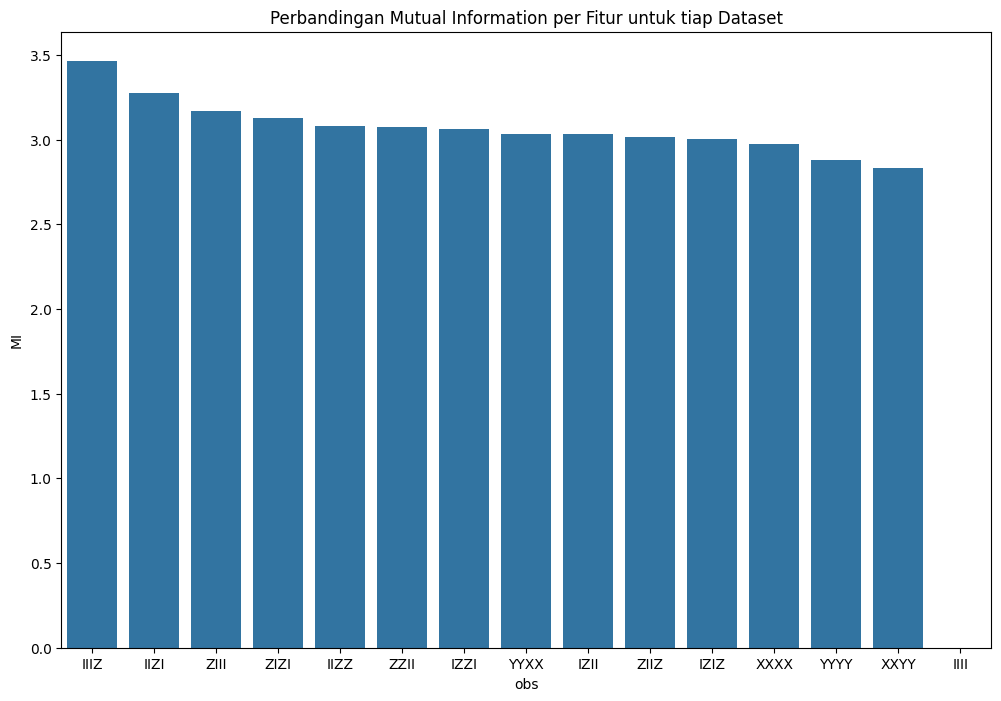

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gabungkan semua hasil ke satu DataFrame
mi_df = pd.DataFrame(results).sort_values(by='MI', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(data=mi_df,x='obs',y='MI')
plt.title('Perbandingan Mutual Information per Fitur untuk tiap Dataset')
plt.show()